<a href="https://colab.research.google.com/github/aasimusman1212-cyber/basics-of-ml/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 — Machine Learning Workflow Using Scikit-Learn Only

This notebook contains only **scikit-learn based model building**.


## Projects

| Project | Dataset | Task | Model |
|---|---|---|---|
| Project 1 | Insurance CSV | Regression | Linear Regression |
| Project 2 | Diabetes CSV | Classification | Decision Tree |
| Project 3 | Iris CSV | Clustering | K-Means |

# Project 1 — Insurance Charge Prediction

## Task

Predict medical insurance `charges`.

## Dataset

Insurance dataset

## Model

Linear Regression

## Step 1 — Import pandas

In [ ]:
import pandas as pd

## Step 2 — Give the insurance dataset path

In [ ]:
insurance_path = "/content/Health_insurance.csv"

# Windows example:
# insurance_path = r"C:\Users\Student\Downloads\insurance.csv"

# Google Colab example:
# insurance_path = "/content/insurance.csv"

## Step 3 — Load the insurance dataset

In [ ]:
insurance = pd.read_csv(insurance_path)

print("Insurance dataset loaded successfully.")

Insurance dataset loaded successfully.


## Step 4 — Display first five rows

In [ ]:
insurance.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## Step 5 — Display last five rows

In [ ]:
insurance.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


## Step 6 — Display rows and columns

In [ ]:
print("Rows:", insurance.shape[0])
print("Columns:", insurance.shape[1])

Rows: 1338
Columns: 7


## Step 7 — Display column names

In [ ]:
print(insurance.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


## Step 8 — Display data types

In [ ]:
insurance.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


## Step 9 — Display dataset information

In [ ]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Step 10 — Display statistical description

In [ ]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Step 11 — Identify input and target variables

In [ ]:
insurance_input_columns = [
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region"
]

insurance_target_column = "charges"

print("Input variables:", insurance_input_columns)
print("Target variable:", insurance_target_column)

Input variables: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target variable: charges


## Step 12 — Check duplicate rows

In [ ]:
print("Duplicate rows:", insurance.duplicated().sum())

Duplicate rows: 1


## Step 13 — Remove duplicate rows

In [ ]:
insurance = insurance.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", insurance.shape)

Shape after removing duplicates: (1337, 7)


## Step 14 — Check missing values


In [ ]:
insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Step 15 — Plot numerical data to check skewness

Use this rule:

- Skewness between `-0.5` and `0.5` → use **mean**
- Skewness less than `-0.5` or greater than `0.5` → use **median**
- Categorical column → use **mode**

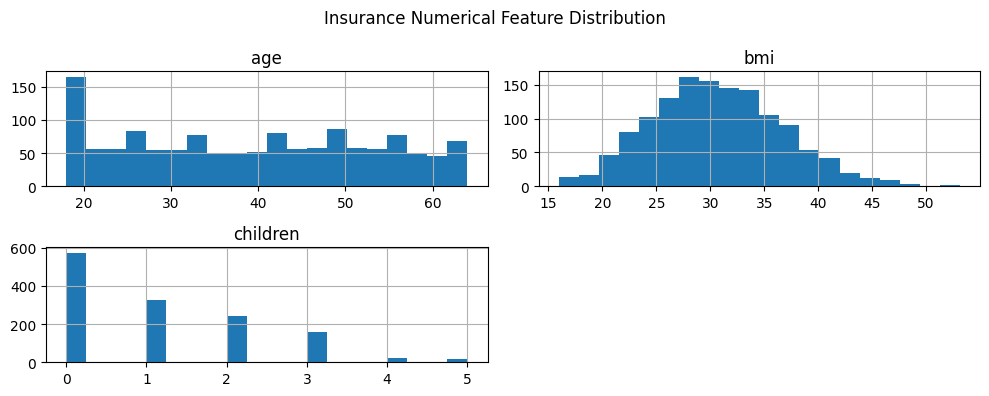

In [ ]:
import matplotlib.pyplot as plt

insurance_numeric_columns = [
    "age",
    "bmi",
    "children"
]

insurance[insurance_numeric_columns].hist(
    bins=20,
    figsize=(10, 4)
)

plt.suptitle("Insurance Numerical Feature Distribution")
plt.tight_layout()
plt.show()

## Step 16 — Calculate skewness

In [ ]:
insurance[insurance_numeric_columns].skew()

,0
age,0.054781
bmi,0.283914
children,0.937421


## Step 17 — Decide mean or median

In [ ]:
for column in insurance_numeric_columns:
    skew_value = insurance[column].skew()

    if -0.5 <= skew_value <= 0.5:
        print(column, "-> Use mean")
    else:
        print(column, "-> Use median")

age -> Use mean
bmi -> Use mean
children -> Use median


## Step 18 — Fill numerical missing values

In [ ]:
insurance["age"] = insurance["age"].fillna(
    insurance["age"].mean()
)

insurance["bmi"] = insurance["bmi"].fillna(
    insurance["bmi"].mean()
)

insurance["children"] = insurance["children"].fillna(
    insurance["children"].median()
)

## Step 19 — Fill categorical missing values using mode

In [ ]:
insurance["sex"] = insurance["sex"].fillna(
    insurance["sex"].mode()[0]
)

insurance["smoker"] = insurance["smoker"].fillna(
    insurance["smoker"].mode()[0]
)

insurance["region"] = insurance["region"].fillna(
    insurance["region"].mode()[0]
)

## Step 20 — Remove rows where target value is missing

*   List item
*   List item



In [ ]:
insurance = insurance.dropna(subset=["charges"])

## Step 21 — Verify missing values

In [ ]:
insurance.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Step 22 — Encode categorical columns

In [ ]:
insurance_encoded = pd.get_dummies(
    insurance,
    columns=["sex", "smoker", "region"],
    dtype=int
)

insurance_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


## Step 23 — Separate input and target variables

In [ ]:
X_insurance = insurance_encoded.drop(
    "charges",
    axis=1
)

y_insurance = insurance_encoded["charges"]

print("Input shape:", X_insurance.shape)
print("Target shape:", y_insurance.shape)

Input shape: (1337, 11)
Target shape: (1337,)


## Step 24 — Split training and testing data

In [ ]:
from sklearn.model_selection import train_test_split

X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(
    X_insurance,
    y_insurance,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train_insurance.shape[0])
print("Testing rows:", X_test_insurance.shape[0])

Training rows: 1069
Testing rows: 268


## Step 25 — Standardize numerical columns

In [ ]:
from sklearn.preprocessing import StandardScaler

insurance_scaler = StandardScaler()

scale_columns = [
    "age",
    "bmi",
    "children"
]

X_train_insurance_scaled = X_train_insurance.copy()
X_test_insurance_scaled = X_test_insurance.copy()

X_train_insurance_scaled[scale_columns] = insurance_scaler.fit_transform(
    X_train_insurance[scale_columns]
)

X_test_insurance_scaled[scale_columns] = insurance_scaler.transform(
    X_test_insurance[scale_columns]
)

# Build Linear Regression Model

## Step 26 — Import and create Linear Regression model

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

## Step 27 — Train the model

In [ ]:
linear_model.fit(
    X_train_insurance_scaled,
    y_train_insurance
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Step 28 — Predict test data

In [ ]:
insurance_predictions = linear_model.predict(
    X_test_insurance_scaled
)

## Step 29 — Compare actual and predicted values

In [ ]:
insurance_result = pd.DataFrame({
    "Actual Charges": y_test_insurance.values,
    "Predicted Charges": insurance_predictions
})

insurance_result.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


## Step 30 — Evaluate the model

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_test_insurance,
    insurance_predictions
)

mse = mean_squared_error(
    y_test_insurance,
    insurance_predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test_insurance,
    insurance_predictions
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4177.045561036324
MSE: 35478020.6752356
RMSE: 5956.342894363587
R2 Score: 0.8069287081198012


## Step 31 — Plot actual vs predicted values

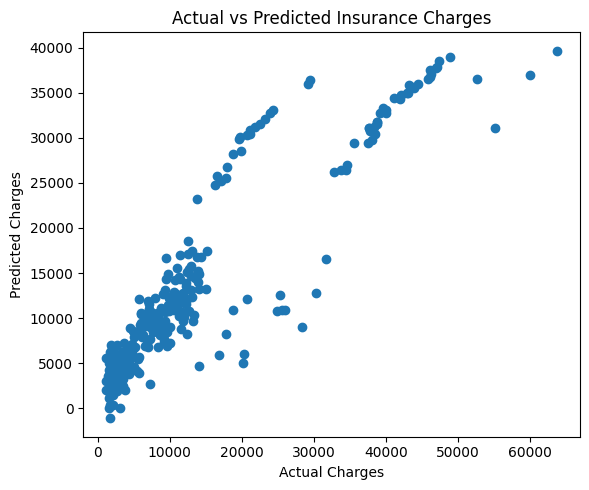

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test_insurance,
    insurance_predictions
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.tight_layout()
plt.show()

# Predict Insurance Charges for Unknown Customer

## Step 32 — Create unknown customer data

In [ ]:
new_customer = pd.DataFrame({
    "age": [35],
    "sex": ["male"],
    "bmi": [27.5],
    "children": [2],
    "smoker": ["yes"],
    "region": ["southeast"]
})

new_customer

,age,sex,bmi,children,smoker,region
0,35,male,27.5,2,yes,southeast


## Step 33 — Encode unknown customer data

In [ ]:
new_customer_encoded = pd.get_dummies(
    new_customer,
    columns=["sex", "smoker", "region"],
    dtype=int
)

new_customer_encoded = new_customer_encoded.reindex(
    columns=X_insurance.columns,
    fill_value=0
)

## Step 34 — Standardize unknown customer data

In [ ]:
new_customer_encoded[scale_columns] = insurance_scaler.transform(
    new_customer_encoded[scale_columns]
)

## Step 35 — Predict unknown customer insurance charge

In [ ]:
unknown_customer_prediction = linear_model.predict(
    new_customer_encoded
)[0]

print("Predicted insurance charge:", unknown_customer_prediction)

Predicted insurance charge: 6484.570845988486
